In [7]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [17]:
#Importing all 3 files, grouping them to see each contributor's total contribution, and sorting them in descending order.
#Replace csv names with the names of your files. 
df1 = pd.read_csv('Eugene Vindman.csv')
df1 = df1.groupby('contributor_name')['contribution_receipt_amount'].sum().reset_index()
df1 = df1.sort_values(by='contribution_receipt_amount', ascending=False)

df2 = pd.read_csv('Alexandria Ocasio-Cortez.csv')
df2 = df2.groupby('contributor_name')['contribution_receipt_amount'].sum().reset_index()
df2 = df2.sort_values(by='contribution_receipt_amount', ascending=False)

df3 = pd.read_csv('Raja Krishnamoorthi.csv')
df3 = df3.groupby('contributor_name')['contribution_receipt_amount'].sum().reset_index()
df3 = df3.sort_values(by='contribution_receipt_amount', ascending=False)

dfs = [df1, df2, df3]

C:\Users\demus\AppData\Local\Temp\ipykernel_888\4090336333.py:3: DtypeWarning: Columns (21,40,41,42,43,44,47,48,49,50) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv('Eugene Vindman.csv')
C:\Users\demus\AppData\Local\Temp\ipykernel_888\4090336333.py:7: DtypeWarning: Columns (41,42,43,47,48) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv('Alexandria Ocasio-Cortez.csv')
C:\Users\demus\AppData\Local\Temp\ipykernel_888\4090336333.py:11: DtypeWarning: Columns (40,41,42,43,47,48,49,50,59) have mixed types. Specify dtype option on import or set low_memory=False.
  df3 = pd.read_csv('Raja Krishnamoorthi.csv')


In [18]:
df1.head(50)


,contributor_name,contribution_receipt_amount
38,ACTBLUE,5645811.80
11363,VINDMAN VICTORY FUND,78036.35
3836,GIVEGREEN,67366.87
11372,VIRGINIA CONGRESSIONAL VICTORY FUND,58080.89
111,AISLE 518 STRATEGIES LLC,45000.00
205,AMERIPAC: THE FUND FOR A GREATER AMERICA,32483.00
1827,CITIZENS BANK,29338.85
9719,SCHIFF VINDMAN VICTORY FUND,29219.97
2598,DIGIDEMS COMMITTEE,25605.00
11892,WINDEM LLC,19800.00


In [19]:
df2.head(50)


,contributor_name,contribution_receipt_amount
49,ACTBLUE,4184024.53
266,AMALGAMATED BANK,208440.38
11877,THE SQUAD VICTORY FUND - UNITEMIZED,114502.63
9622,PROGRESSIVE VOICES FOR PEACE,62053.46
11876,THE SQUAD VICTORY FUND,58000.00
8621,NEW YORK STATE INSURANCE FUND,18916.46
3404,EMBLEM HEALTH,17355.84
9623,PROGRESSIVE VOICES FOR PEACE - UNITEMIZED,14317.02
1335,BREX,12805.00
7294,MACHINISTS NON PARTISAN POL. LEAGUE OF THE INT...,10000.00


In [20]:
df3.head(50)

,contributor_name,contribution_receipt_amount
21,ACTBLUE,3257017.02
720,CITIBANK,1196964.04
872,"DEMOCRACY ENGINE, INC., PAC",108150.00
3267,SAPPHIRE STRATEGIES,35050.00
3533,"SINGH, MANJIT",13200.00
822,"DANDAMUDI, SANDYA",13200.00
3219,"SAKA, SAMUEL",13200.00
2586,"NOWACKI, JAMES",13200.00
1716,JSTREETPAC,11500.00
3800,THE COUNCIL OF INSURANCE AGENTS & BROKERS POLI...,10000.00


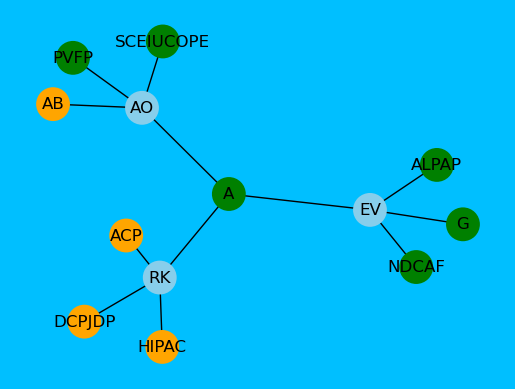

In [29]:
#This is where you place all of the information about the congress members! Include their names, and the funders/ donors that you chose (in their respected categories ofc)
#This is all you really need to change. IF you are working with Democrats, look for the other comment in the loop and change the color to "skyblue" (or whatever color you prefer ). 
members = [
    {
        "name": "Eugene Vindman",
        "fossil": [],
        "green": ["ACTBLUE", "GIVEGREEN", "NEW DEMOCRAT COALITION ACTION FUND", "AIR LINE PILOTS ASSOCIATION PAC"]
    },
    {
        "name": "Alexandria Ocasio-Cortez",
        "fossil": ["AMALGAMATED BANK"],
        "green": ["ACTBLUE", "PROGRESSIVE VOICES FOR PEACE", "SEIU COPE (SERVICE EMPLOYEES INTERNATIONAL UNION COMMITTEE ON POLITICAL EDUCATION)"]
    },
    {
        "name": "Raja Krishnamoorthi",
        "fossil": ["DEERE & COMPANY PAC (AKA JOHN DEERE PAC)", "HONEYWELL INTERNATIONAL POLITICAL ACTION COMMITTEE", "AAR CORP PAC"],
        "green": ["ACTBLUE"]
    }
]

Gs = [nx.Graph(), nx.Graph(), nx.Graph()]

for i, (df, m) in enumerate(zip(dfs, members)):
    df["stance"] = "gray"
    df["target"] = m["name"]

    #Play around with these colors if you'd like, defaults are orange and green.
    df.loc[df["contributor_name"].isin(m["fossil"]), "stance"] = "orange"
    df.loc[df["contributor_name"].isin(m["green"]), "stance"] = "green"

    Gs[i] = nx.from_pandas_edgelist(df[df["contributor_name"].isin(m["fossil"] + m["green"])], source="contributor_name", target="target", edge_attr=["stance"])

    for _, row in df.iterrows():
        if row["contributor_name"] in Gs[i].nodes:
            Gs[i].nodes[row["contributor_name"]]["color"] = row["stance"]

    #If working with Democrats, change to "skyblue"
    Gs[i].nodes[m["name"]]["color"] = "skyblue"

G1 = Gs[0]
G1.add_nodes_from(Gs[1].nodes(data=True))
G1.add_nodes_from(Gs[2].nodes(data=True))
G1.add_edges_from(Gs[1].edges(data=True))
G1.add_edges_from(Gs[2].edges(data=True))

key = []
labels = {}
for n in G1.nodes():
    parts = n.split() 
    letters = [p[0] for p in parts if p[0].isalpha()]
    labels[n] = "".join(letters)
    key.append({labels[n] : n})


node_colors = [G1.nodes[n].get("color", "gray") for n in G1.nodes()]

fig, ax = plt.subplots()
pos = nx.spring_layout(G1, k=1, iterations=100)
nx.draw(G1, pos=pos, with_labels=True, labels=labels, node_color=node_colors, node_size=500, edge_color='black', linewidths=2)
ax.axis('off')
#You can change the background color here. 
fig.set_facecolor('deepskyblue')
plt.show()

In [30]:
print("Key: ")
for item in key:
    for k, v in item.items( ):
        print(f"{k} = {v}") 


Key: 
A = ACTBLUE
EV = Eugene Vindman
G = GIVEGREEN
NDCAF = NEW DEMOCRAT COALITION ACTION FUND
ALPAP = AIR LINE PILOTS ASSOCIATION PAC
AO = Alexandria Ocasio-Cortez
AB = AMALGAMATED BANK
PVFP = PROGRESSIVE VOICES FOR PEACE
SCEIUCOPE = SEIU COPE (SERVICE EMPLOYEES INTERNATIONAL UNION COMMITTEE ON POLITICAL EDUCATION)
RK = Raja Krishnamoorthi
DCPJDP = DEERE & COMPANY PAC (AKA JOHN DEERE PAC)
ACP = AAR CORP PAC
HIPAC = HONEYWELL INTERNATIONAL POLITICAL ACTION COMMITTEE
